Imports:

In [51]:
from __future__ import annotations
import functools
import math
import numpy as np
import itertools
from qiskit import QuantumCircuit
from qiskit.circuit.library import XXMinusYYGate, XXPlusYYGate
from qiskit_nature.second_q.circuit.library import FermionicGaussianState
from qiskit_nature.second_q.hamiltonians import QuadraticHamiltonian

Helper functions:

In [52]:
def orbital_combinations(
    n_modes: int, threshold: Optional[int] = None
) -> Iterable[tuple[int, ...]]:
    if threshold is None:
        threshold = n_modes
    yield ()
    yield tuple(range(n_modes))
    for i in range(threshold):
        yield (i,)
        yield tuple(range(i)) + tuple(range(i + 1, n_modes))

def orbital_permutations(n_modes: int) -> Iterable[tuple[int, ...]]:
    permutation = list(range(n_modes))
    for _ in range(math.ceil(n_modes / 2)):
        yield tuple(permutation)
        for i in range(0, n_modes - 1, 2):
            a, b = permutation[i], permutation[i + 1]
            permutation[i], permutation[i + 1] = b, a
        for i in range(1, n_modes - 1, 2):
            a, b = permutation[i], permutation[i + 1]
            permutation[i], permutation[i + 1] = b, a

def measurement_labels(n_modes: int) -> Iterable[tuple[tuple[int, ...], str]]:
    yield tuple(range(n_modes)), "number"
    for permutation in orbital_permutations(n_modes):
        yield permutation, "tunneling_plus_even"
        yield permutation, "tunneling_plus_odd"
        yield permutation, "tunneling_minus_even"
        yield permutation, "tunneling_minus_odd"
        yield permutation, "superconducting_plus_even"
        yield permutation, "superconducting_plus_odd"
        yield permutation, "superconducting_minus_even"
        yield permutation, "superconducting_minus_odd"

@functools.lru_cache
def kitaev_hamiltonian(
    n_modes: int,
    tunneling: float,
    superconducting: Union[float, complex],
    chemical_potential: float,
) -> QuadraticHamiltonian:
    eye = np.eye(n_modes)
    upper_diag = np.diag(np.ones(n_modes - 1), k=1)
    lower_diag = np.diag(np.ones(n_modes - 1), k=-1)
    hermitian_part = -tunneling * (upper_diag + lower_diag) + chemical_potential * eye
    antisymmetric_part = superconducting * (upper_diag - lower_diag)
    constant = -0.5 * chemical_potential * n_modes
    return QuadraticHamiltonian(
        hermitian_part=hermitian_part,
        antisymmetric_part=antisymmetric_part,
        constant=constant,
    )

def measure_interaction_op(circuit: QuantumCircuit, label: str) -> QuantumCircuit:
    if label == "number":
        circuit = circuit.copy()
        circuit.measure_all()
        return circuit
    if label.startswith("tunneling_plus"):
        gate = XXPlusYYGate(np.pi / 2, -np.pi / 2)
    elif label.startswith("tunneling_minus"):
        gate = XXPlusYYGate(np.pi / 2, -np.pi)
    elif label.startswith("superconducting_plus"):
        gate = XXMinusYYGate(np.pi / 2, -np.pi / 2)
    else:
        gate = XXMinusYYGate(np.pi / 2, -np.pi)
    if label.endswith("even"):
        start_index = 0
    else:
        start_index = 1
    circuit = circuit.copy()
    for i in range(start_index, circuit.num_qubits-1, 2):
        circuit.append(gate, [i, i+1])
    circuit.measure_all()
    return circuit

def _all_real_rz_gates(circuit: QuantumCircuit, rtol=1e-5, atol=1e-8) -> bool:
    for instruction in circuit.data:
        if isinstance(instruction.operation, XXPlusYYGate):
            _, beta = instruction.operation.params
            if not np.isclose(
                (beta + np.pi / 2) % np.pi, 0.0, rtol=rtol, atol=atol
            ) and not np.isclose((beta + np.pi / 2) % np.pi, np.pi, atol=1e-8):
                return False
    return True

Parameters:

In [66]:
n_modes = 3
tunneling_values = [-1.0]
superconducting_values = [1.0]
chemical_potential_values = list(np.linspace(0.0, 3.0, num=5))
occupied_orbitals_list = list(orbital_combinations(n_modes, threshold=n_modes-1))

Circuit generation:

In [67]:
circuits = []
for (
    tunneling, 
    superconducting, 
    chemical_potential, 
    occupied_orbitals
) in itertools.product(
    tunneling_values, 
    superconducting_values, 
    chemical_potential_values, 
    occupied_orbitals_list
):
    for permutation, label in measurement_labels(n_modes):
        hamiltonian = kitaev_hamiltonian(
            n_modes,
            tunneling=tunneling,
            superconducting=superconducting,
            chemical_potential=chemical_potential,
        )
        transformation_matrix, _, _ = hamiltonian.diagonalizing_bogoliubov_transform()
        perm = np.array(permutation)
        full_permutation = np.concatenate([perm, perm+n_modes])
        for i in range(n_modes):
            transformation_matrix[i, :] = transformation_matrix[i, full_permutation]
        base_circuit = FermionicGaussianState(transformation_matrix, occupied_orbitals)
        if "_minus_" in label and _all_real_rz_gates(base_circuit, atol=1e-6):
            continue
        circuits.append(measure_interaction_op(base_circuit, label))
len(circuits)

270

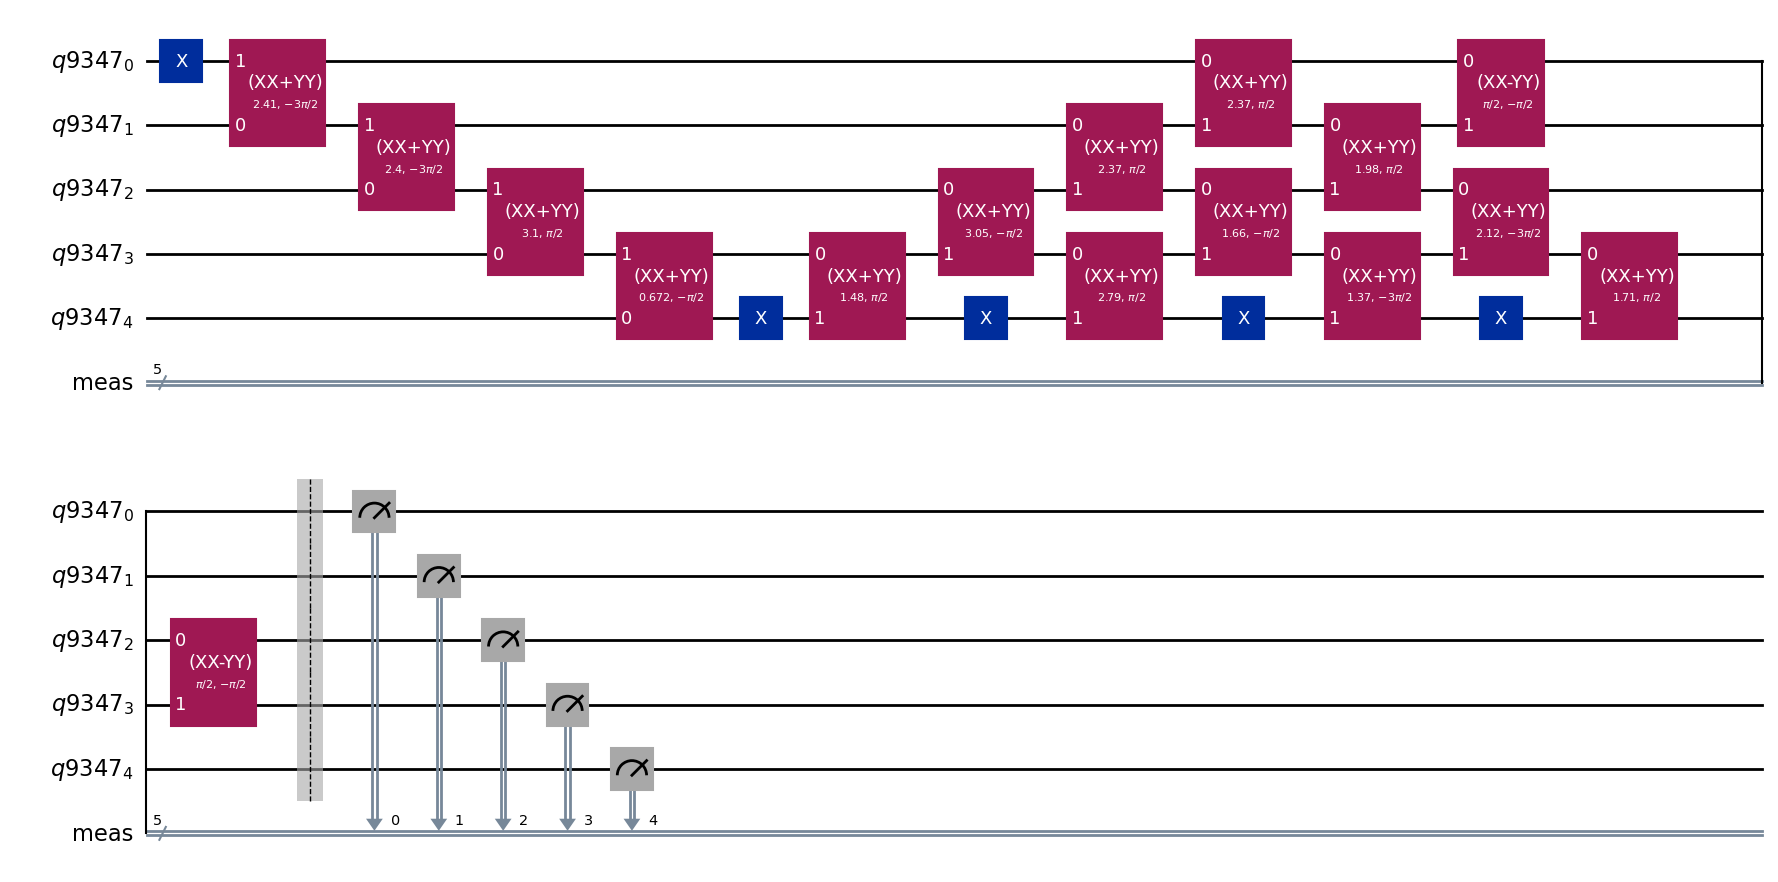

In [62]:
circuits[37].draw(output="mpl")